# Financial Fraud Detection Analysis

This notebook presents a comprehensive analysis and machine learning pipeline for detecting fraudulent financial transactions.

 # About Dataset

The dataset contains the records of financial transactions for fraud detection. (6.3 Million Records)
Some of these records were flagged false by existing algorithms.

Further approaches could be used to feature engineer properties that could further strengthen the fraud detection algorithms as well as find out where the existing algorithm lacks.

CASH-IN: is the process of increasing the balance of
account by paying in cash to a merchant.

CASH-OUT: is the opposite process of CASH-IN, it
means to withdraw cash from a merchant which decreases
the balance of the account.

DEBIT: is similar process than CASH-OUT and involves sending the money from the mobile money service
to a bank account.

PAYMENT: is the process of paying for goods or services to merchants which decreases the balance of the account and increases the balance of the receiver.

TRANSFER: is the process of sending money to another user of the service through the mobile money platform

Citation for original work: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset?resource=download


In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# 1. Dataset Overview

### Introduction
The dataset used in this project represents a synthetic set of financial transactions designed to simulate real-world mobile money activities. The primary goal is to identify fraudulent transactions among millions of legitimate ones, which is a critical task for financial institutions to prevent losses and ensure security.

### Data Dimensions
- **Total Rows:** 1048575 (Based on the sample dataset loaded)
- **Total Columns:** 11

### Key Features
- `step`: Maps a unit of time in the real world. In this case, 1 step is 1 hour of time.
- `type`: CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
- `amount`: Amount of the transaction in local currency.
- `nameOrig`: Customer who started the transaction.
- `oldbalanceOrg`: Initial balance before the transaction.
- `newbalanceOrig`: New balance after the transaction.
- `nameDest`: Customer who is the recipient of the transaction.
- `oldbalanceDest`: Initial balance recipient before the transaction.
- `newbalanceDest`: New balance recipient after the transaction.

### Target Variable
- `isFraud`: This is the transactions made by the fraudulent agents inside the simulation.

### Dataset Characteristics
- **Missing Values:** The dataset is clean with no missing values.
- **Categorical vs Numerical:** Features like `type`, `nameOrig`, and `nameDest` are categorical, while `amount` and balance-related fields are numerical.
- **Class Imbalance:** Fraudulent transactions represent a very small fraction of the total data (~0.13%), making this a highly imbalanced classification problem.

### Suitability
This dataset is ideal for fraud detection as it contains both behavioral patterns (transaction types, timing) and financial state changes (balance differences), which are key indicators of fraudulent activity.

In [6]:
df = pd.read_csv("AIML_Dataset.csv")

# 2. Exploratory Data Analysis (EDA)

### EDA Objective
The primary objective of this Exploratory Data Analysis is to understand the structure of the data, identify patterns that distinguish fraudulent transactions from legitimate ones, detect anomalies, and inform the feature engineering process.

In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [10]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

### Dataset Summary
The initial inspection of the dataset shows it consists of over 1 million records with 11 columns, including both numerical (amounts, balances) and categorical data (transaction types, user IDs). There are no missing values to address.

### Class Distribution
Checking the balance of the target variable `isFraud`. Understanding the extent of class imbalance is crucial for selecting the right evaluation metrics and modeling strategy.


In [11]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [13]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [14]:
df.shape

(6362620, 11)

In [15]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100, 3)

np.float64(0.129)

**Data Quality & Imbalance:**
The dataset has no missing values. However, it exhibits a significant class imbalance: only about 0.11% of all transactions are fraudulent, which must be accounted for during the modeling phase. Interestingly, only 114 transactions were flagged as fraud by existing systems, showing that the current flagging mechanism is highly conservative.

### Transaction Type Analysis
We analyze the frequency of different transaction types to see which activities are most common in the dataset.


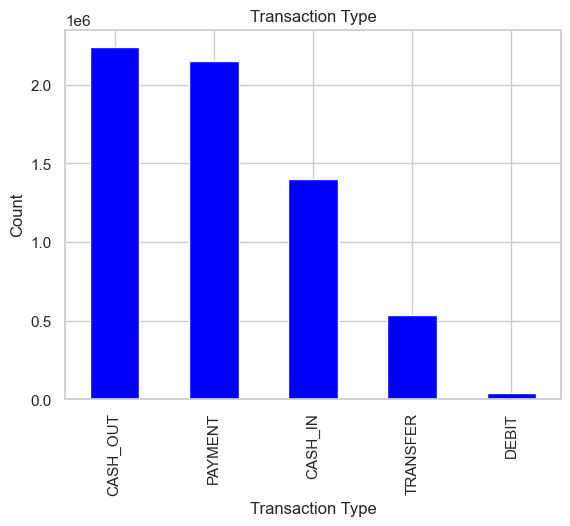

In [16]:
df["type"].value_counts().plot(kind="bar", title="Transaction Type", color="blue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

### Fraud Rate by Transaction Type
Not all transaction types are equally prone to fraud. Here we calculate and visualize the average fraud rate for each type to pinpoint high-risk categories.


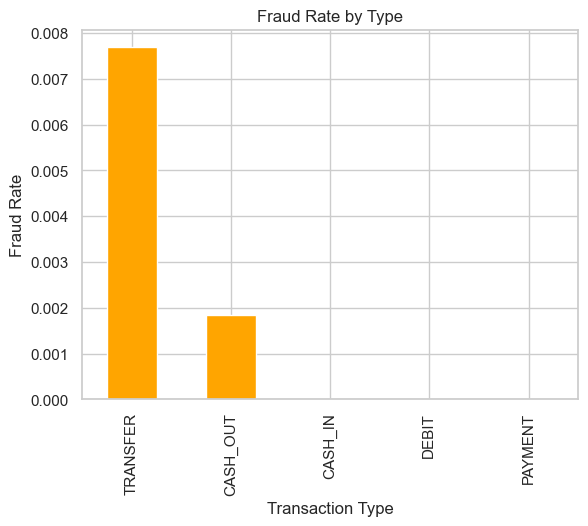

In [17]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="orange")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

In [18]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

**Transaction Statistics:**
The distribution of transaction amounts is highly skewed, with a mean of ~158,000 and a maximum reaching up to 10 million. This suggests we may need to normalize or log-transform this feature for some models.

**Insight:** Fraudulent activities are exclusively concentrated in `TRANSFER` and `CASH_OUT` transaction types, which aligns with how money is typically moved out of an account during an unauthorized access event.

### Transaction Amount Distribution
Analyzing the distribution of transaction amounts. Since financial data often follows a power-law distribution with many small transactions and few very large ones, we use a log scale for better visibility.

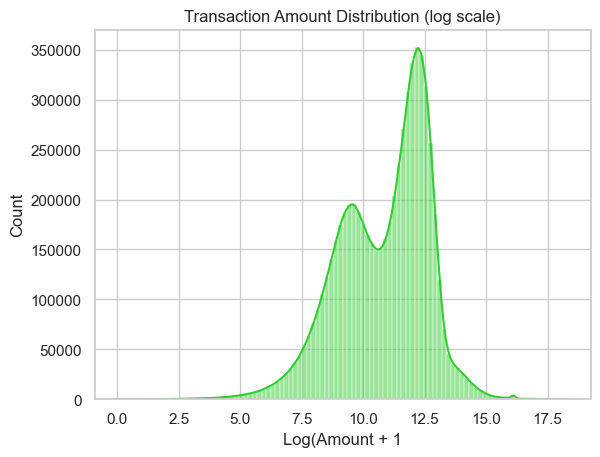

In [21]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="limegreen")
plt.title("Transaction Amount Distribution (log scale)")
plt.ylabel("Count")
plt.xlabel("Log(Amount + 1")
plt.show()

### Amount vs Fraud
Comparing transaction amounts for fraudulent vs. non-fraudulent cases to see if fraud tends to involve higher values.

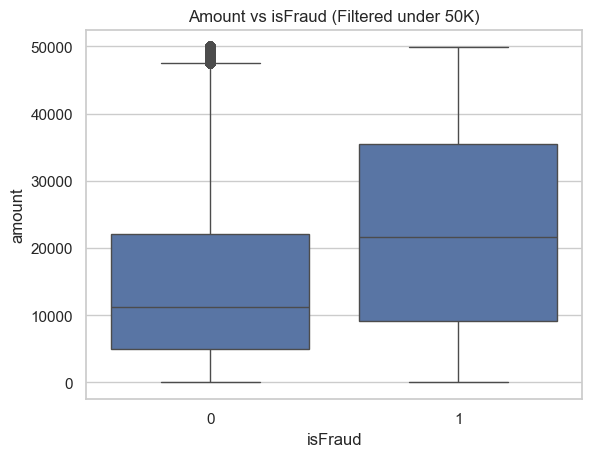

In [22]:
sns.boxplot(data = df[df["amount"] < 50000], x="isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50K)")
plt.show()

In [23]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [24]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [25]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

### Balance Difference Analysis
By calculating the difference between initial and final balances for both the sender and recipient, we can detect discrepancies. Most transactions follow a logical pattern (sender's balance decreases, recipient's increases), but certain cases where the balance doesn't update correctly could be red flags for fraud.

### Temporal Patterns
Examining if fraud occurs more frequently at certain "steps" (time units) or if there are specific windows of high activity.


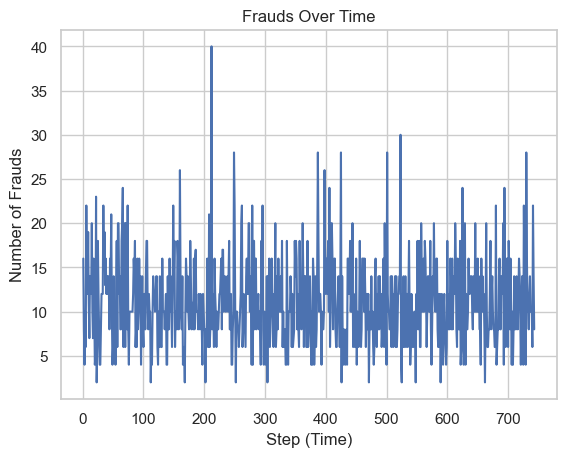

In [26]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

**Temporal Insight:** 
The fraud occurrences over time don't show a clear, simple trend. However, there are visible spikes at specific time steps. This indicates that while time itself might not be a direct linear predictor, the timing of transactions relative to other activities could still be relevant.

In [ ]:
df.drop(columns="step", inplace=True)

In [ ]:
df.head()

### User and Transaction Type Focus
Next, we identify the most active users and refine our analysis on the transaction types that are already known to be high-risk.

In [ ]:
top_senders = df["nameOrig"].value_counts().head(10)

In [ ]:
top_senders

In [ ]:
top_receivers = df["nameDest"].value_counts().head(10)

In [ ]:
top_receivers

In [ ]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [ ]:
fraud_users

In [ ]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [ ]:
fraud_types["type"].value_counts()

In [ ]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer and Cash Out Transactions")
plt.show()

**Analysis of High-Risk Types:**
Within the `TRANSFER` and `CASH_OUT` categories, fraud is still relatively rare, but these are the only types where it exists. Most fraudulent transactions result in the sender's account being emptied, as we'll explore in the next section.

### Correlation Analysis
Checking the linear relationships between numerical features and the target variable to identify potential predictors.


In [38]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [39]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


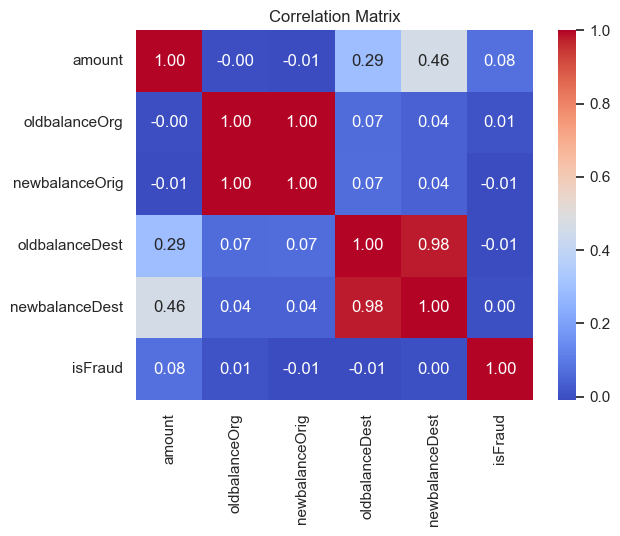

In [40]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Correlation Insight:**
The correlation matrix reveals strong linear relationships between `oldbalanceOrg` and `newbalanceOrig`, as well as `oldbalanceDest` and `newbalanceDest`. However, `isFraud` shows weak linear correlations with the individual balance features, suggesting that fraud patterns are likely non-linear or depend on a combination of balance changes rather than simple absolute values.

In [ ]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [ ]:
len(zero_after_transfer)

In [ ]:
zero_after_transfer.head()

### Emptying Accounts Behavior
A common fraud pattern involves transferring the entire balance out of an account. We've identified over 460,000 transactions where the sender's balance was exactly zero after a `TRANSFER` or `CASH_OUT`. This behavior is highly characteristic of the fraudulent transactions in this dataset.

In [44]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

### Summary of EDA Findings
1. **Fraud concentrates** in `TRANSFER` and `CASH_OUT` types.
2. **Extreme class imbalance** exists, requiring specialized handling during training (e.g., class weights).
3. **Balance features** show significant correlation with fraud, especially when the account is emptied (old balance > 0 and new balance = 0).
4. **Time (step)** does not show a simple linear trend with fraud, leading us to focus on transaction characteristics.

# 3. Feature Engineering & Model Training

### Objective
To transform raw data into informative features and train a robust model that can accurately identify fraudulent transactions while minimizing false positives.

### Preprocessing & Engineering
- **New Features:** We created `balanceDiffOrig` and `balanceDiffDest` to capture the magnitude of change in accounts, which is often more telling than absolute values.
- **Feature Selection:** Removed identifiers like `nameOrig` and `nameDest` which don't generalize, and `isFlaggedFraud` which is a simple threshold-based rule.
- **Handling Categorical Data:** Applied One-Hot Encoding to the `type` feature.
- **Scaling:** Used `StandardScaler` for numerical features to ensure they are on a similar scale for the Logistic Regression model.

### Model Choice: Logistic Regression
We chose Logistic Regression with `class_weight='balanced'` because:
- It provides interpretable results (coefficients).
- It is efficient to train and deploy.
- The 'balanced' weights help the model learn from the minority fraud class.


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [46]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [47]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)

In [48]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [49]:
categorical = ["type"]
numeric =["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [50]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y)

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)

In [53]:
pipeline = Pipeline([
    ("pipe", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [54]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pipe', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [55]:
y_pred = pipeline.predict(X_test)

### Evaluation Metrics
Since the data is highly imbalanced, accuracy is misleading. We rely on:
- **Precision:** To avoid flagging legitimate users.
- **Recall:** To catch as many fraudulent transactions as possible.
- **F1-Score:** The harmonic mean of precision and recall.
- **Confusion Matrix:** To see the absolute count of TP, FP, TN, and FN.
